# 05 - Customer Segmentation (K-Means)

Mengelompokkan pelanggan berdasarkan perilaku finansial menggunakan K-Means Clustering.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("customer_preprocessed.csv")
df.head()

,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant
0,-1.146873,-1.165862,-1.067993,-0.387886,-0.325044,0.0,-1.790369,-1.123271,-1.165862,-1.067993,-0.847497,-0.981108,1.034871,-1.034872,0.335019,-0.946900
1,1.546156,0.414515,-0.319887,0.091887,-0.261130,0.0,0.340547,0.845636,0.414515,-0.319887,1.081289,-0.085078,0.367206,-0.367205,0.335019,0.738472
2,1.429068,0.022949,1.041842,-0.387886,-1.905859,0.0,1.473452,0.058073,0.022949,1.041842,0.116896,-0.085078,0.100139,-0.100139,-0.960562,0.100763
3,1.136347,0.134582,-1.164659,-0.387886,-0.121680,0.0,-1.056950,1.239417,0.134582,-1.164659,1.563486,-0.085078,0.450664,-0.450664,0.335019,-0.582495
4,0.433818,0.939134,-0.330681,-0.387886,0.694788,0.0,-0.015149,1.633198,0.939134,-0.330681,2.045682,-0.085078,0.515576,-0.515576,0.335019,-0.992451


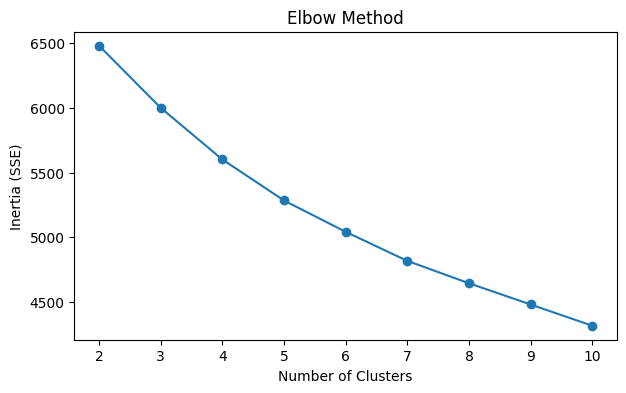

In [ ]:
# Elbow Method
inertia=[]

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(df)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,11),inertia,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

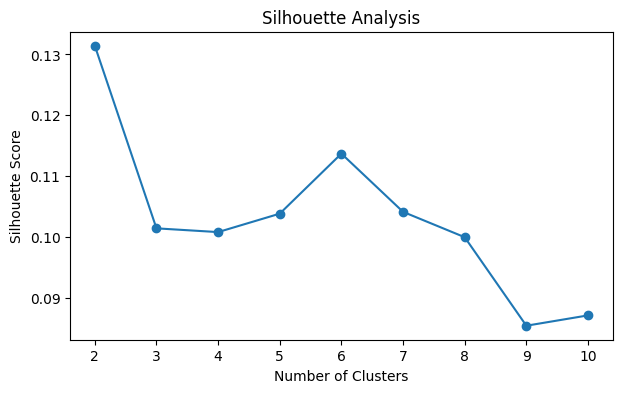

Best K: 2


In [ ]:
# Silhouette Score
scores=[]

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(df)
    scores.append(silhouette_score(df,labels))

plt.figure(figsize=(7,4))
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

best_k = scores.index(max(scores))+2
print("Best K:",best_k)


In [ ]:
# Train Final Model
kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=10)
clusters=kmeans.fit_predict(df)

clustered=df.copy()
clustered["Cluster"]=clusters

clustered.head()

,CustomerAge,TransactionAmount,AccountBalance,LoginAttempts,TransactionDuration,TransactionHour,DaysSincePreviousTransaction,TotalTransactionPerAccount,AverageTransaction,AverageBalance,DebitCount,CreditCount,DebitRatio,CreditRatio,FavoriteChannel,FavoriteMerchant,Cluster
0,-1.146873,-1.165862,-1.067993,-0.387886,-0.325044,0.0,-1.790369,-1.123271,-1.165862,-1.067993,-0.847497,-0.981108,1.034871,-1.034872,0.335019,-0.946900,1
1,1.546156,0.414515,-0.319887,0.091887,-0.261130,0.0,0.340547,0.845636,0.414515,-0.319887,1.081289,-0.085078,0.367206,-0.367205,0.335019,0.738472,1
2,1.429068,0.022949,1.041842,-0.387886,-1.905859,0.0,1.473452,0.058073,0.022949,1.041842,0.116896,-0.085078,0.100139,-0.100139,-0.960562,0.100763,1
3,1.136347,0.134582,-1.164659,-0.387886,-0.121680,0.0,-1.056950,1.239417,0.134582,-1.164659,1.563486,-0.085078,0.450664,-0.450664,0.335019,-0.582495,1
4,0.433818,0.939134,-0.330681,-0.387886,0.694788,0.0,-0.015149,1.633198,0.939134,-0.330681,2.045682,-0.085078,0.515576,-0.515576,0.335019,-0.992451,1


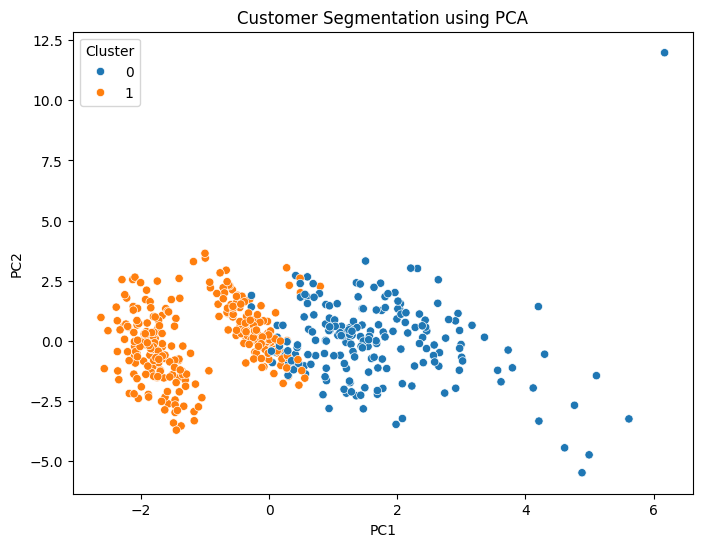

In [ ]:
# PCA Visualization
pca=PCA(n_components=2)
components=pca.fit_transform(df)

plot_df=pd.DataFrame(components,columns=["PC1","PC2"])
plot_df["Cluster"]=clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df,x="PC1",y="PC2",hue="Cluster",palette="tab10")
plt.title("Customer Segmentation using PCA")
plt.show()

In [ ]:
# Cluster Size
clustered["Cluster"].value_counts().sort_index()

,count
Cluster,
0,195
1,300


In [ ]:
# Save Result
clustered.to_csv("customer_clustered.csv",index=False)
print("customer_clustered.csv saved.")

customer_clustered.csv saved.


## Kesimpulan

- Menentukan jumlah cluster optimal menggunakan Elbow Method dan Silhouette Score.
- Melatih model K-Means.
- Memvisualisasikan hasil segmentasi menggunakan PCA.
- Dataset hasil segmentasi disimpan sebagai **customer_clustered.csv** untuk tahap Cluster Profiling.
